# 🔄 Crisis Recovery Strategy — Comprehensive Business Plan

This notebook consolidates findings from all previous analyses and proposes **data-driven recovery strategies** for:
- **Customers** — Win-back campaigns and retention
- **Restaurants** — Partner recovery and SLA guarantees
- **Delivery Operations** — Performance improvement and capacity planning
- **Brand & Reputation** — Sentiment recovery and communication
- **Financial Recovery** — Prioritized investments and projected ROI

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})

COLORS = {'critical': '#e74c3c', 'high': '#f39c12', 'medium': '#3498db',
           'low': '#2ecc71', 'neutral': '#95a5a6'}

In [2]:
def load_data(table):
    return pd.read_csv(f'rpc_18_inputs_for_participants//rpc_18_inputs_for_participants//RPC_18_Datasets//{table}.csv')

# Load data
customers = load_data('dim_customer')
orders = load_data('fact_orders')
ratings = load_data('fact_ratings')
delivery = load_data('fact_delivery_performance_enhanced')
if 'Unnamed: 0' in delivery.columns:
    delivery.drop(columns=['Unnamed: 0'], inplace=True)
restaurant = load_data('restaurant_corrected')
if 'Unnamed: 0' in restaurant.columns:
    restaurant.drop(columns=['Unnamed: 0'], inplace=True)

orders['order_timestamp'] = pd.to_datetime(orders['order_timestamp'])
orders['month'] = orders['order_timestamp'].dt.to_period('M')
orders['month_num'] = orders['order_timestamp'].dt.month
orders['is_cancelled_flag'] = orders['is_cancelled'].map({'Y': 1, 'N': 0})
orders['period'] = orders['month_num'].apply(lambda m: 'Pre-Crisis' if m <= 5 else 'Crisis')

delivery['delay_mins'] = delivery['actual_delivery_time_mins'] - delivery['expected_delivery_time_mins']

print('Data loaded successfully.')

Data loaded successfully.


---
# 📊 Section 1: Crisis Impact Recap

Quick summary of the damage across all business dimensions before diving into recovery strategies.

In [3]:
# --- Key Crisis Metrics Dashboard ---
pre = orders[orders['period'] == 'Pre-Crisis']
crisis = orders[orders['period'] == 'Crisis']

pre_monthly_orders = pre.groupby('month')['order_id'].count().mean()
crisis_monthly_orders = crisis.groupby('month')['order_id'].count().mean()
order_decline = (crisis_monthly_orders - pre_monthly_orders) / pre_monthly_orders * 100

pre_cancel = pre['is_cancelled_flag'].mean() * 100
crisis_cancel = crisis['is_cancelled_flag'].mean() * 100

pre_revenue = pre.groupby('month')['total_amount'].sum().mean()
crisis_revenue = crisis.groupby('month')['total_amount'].sum().mean()
revenue_decline = (crisis_revenue - pre_revenue) / pre_revenue * 100

pre_delay = delivery.merge(pre[['order_id']], on='order_id')['delay_mins'].mean()
crisis_delay = delivery.merge(crisis[['order_id']], on='order_id')['delay_mins'].mean()

active_rest = restaurant['is_active'].value_counts()
rest_churn_rate = (active_rest.get('N', 0) / len(restaurant) * 100)

# Customers
pre_custs = set(pre['customer_id'].unique())
crisis_custs = set(crisis['customer_id'].unique())
cust_churn = len(pre_custs - crisis_custs) / len(pre_custs) * 100

metrics = {
    'Monthly Orders Decline': f'{order_decline:.1f}%',
    'Cancellation Rate (Pre→Crisis)': f'{pre_cancel:.1f}% → {crisis_cancel:.1f}%',
    'Monthly Revenue Decline': f'{revenue_decline:.1f}%',
    'Avg Delivery Delay (Pre→Crisis)': f'{pre_delay:.1f} → {crisis_delay:.1f} mins',
    'Restaurant Churn Rate': f'{rest_churn_rate:.1f}%',
    'Customer Churn Rate': f'{cust_churn:.1f}%'
}

print('╔══════════════════════════════════════════════════╗')
print('║        CRISIS IMPACT DASHBOARD                  ║')
print('╠══════════════════════════════════════════════════╣')
for k, v in metrics.items():
    print(f'║  {k:<35} {v:>12}  ║')
print('╚══════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════╗
║        CRISIS IMPACT DASHBOARD                  ║
╠══════════════════════════════════════════════════╣
║  Monthly Orders Decline                    -61.2%  ║
║  Cancellation Rate (Pre→Crisis)      6.1% → 11.9%  ║
║  Monthly Revenue Decline                   -63.7%  ║
║  Avg Delivery Delay (Pre→Crisis)     2.0 → 17.6 mins  ║
║  Restaurant Churn Rate                      17.0%  ║
║  Customer Churn Rate                        83.8%  ║
╚══════════════════════════════════════════════════╝


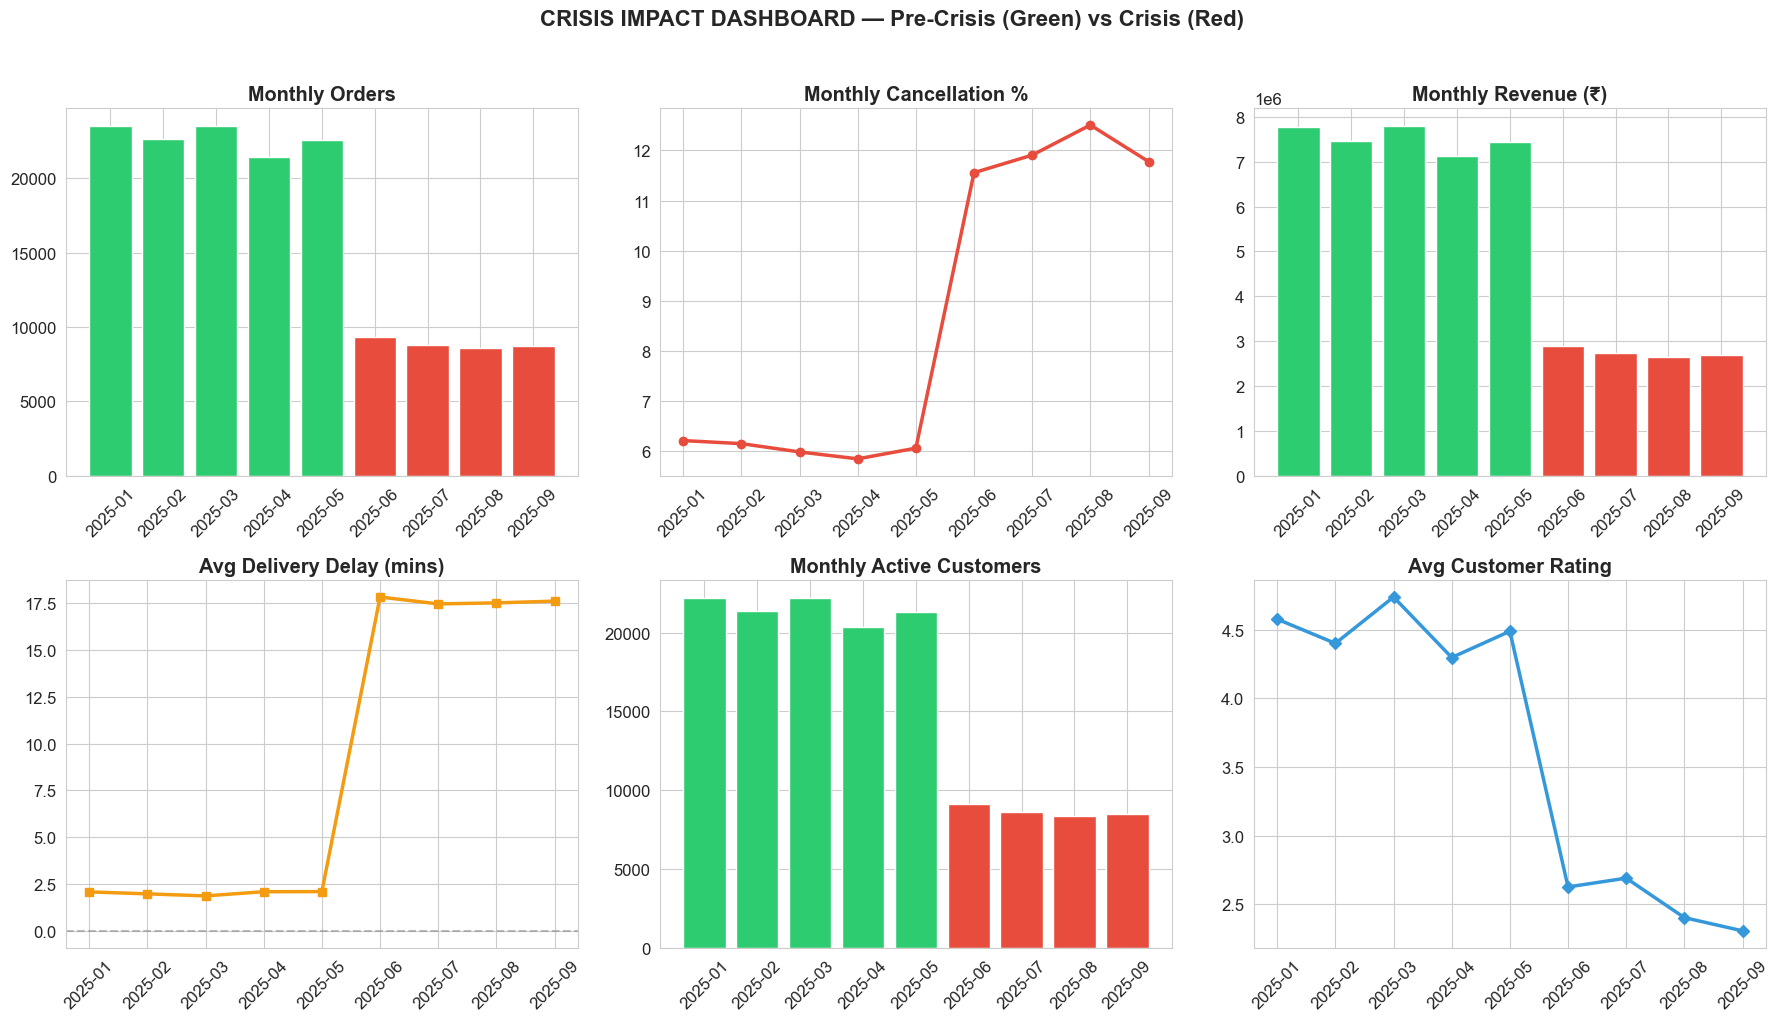

In [4]:
# --- Visual Crisis Dashboard ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Monthly orders
monthly_orders = orders.groupby('month')['order_id'].count().reset_index()
monthly_orders['month_str'] = monthly_orders['month'].astype(str)
colors = [COLORS['low'] if i < 5 else COLORS['critical'] for i in range(len(monthly_orders))]
axes[0,0].bar(monthly_orders['month_str'], monthly_orders['order_id'], color=colors, edgecolor='white')
axes[0,0].set_title('Monthly Orders', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Cancellation rate
monthly_cancel = orders.groupby('month')['is_cancelled_flag'].mean().reset_index()
monthly_cancel['month_str'] = monthly_cancel['month'].astype(str)
monthly_cancel['pct'] = monthly_cancel['is_cancelled_flag'] * 100
axes[0,1].plot(monthly_cancel['month_str'], monthly_cancel['pct'], marker='o', color=COLORS['critical'], linewidth=2.5)
axes[0,1].set_title('Monthly Cancellation %', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Revenue
monthly_rev = orders[orders['is_cancelled_flag']==0].groupby('month')['total_amount'].sum().reset_index()
monthly_rev['month_str'] = monthly_rev['month'].astype(str)
rev_colors = [COLORS['low'] if i < 5 else COLORS['critical'] for i in range(len(monthly_rev))]
axes[0,2].bar(monthly_rev['month_str'], monthly_rev['total_amount'], color=rev_colors, edgecolor='white')
axes[0,2].set_title('Monthly Revenue (₹)', fontweight='bold')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Avg delay
del_monthly = delivery.merge(orders[['order_id', 'month']], on='order_id')
del_monthly_avg = del_monthly.groupby('month')['delay_mins'].mean().reset_index()
del_monthly_avg['month_str'] = del_monthly_avg['month'].astype(str)
axes[1,0].plot(del_monthly_avg['month_str'], del_monthly_avg['delay_mins'], marker='s', color=COLORS['high'], linewidth=2.5)
axes[1,0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1,0].set_title('Avg Delivery Delay (mins)', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Active customers
monthly_cust = orders.groupby('month')['customer_id'].nunique().reset_index()
monthly_cust['month_str'] = monthly_cust['month'].astype(str)
cust_colors = [COLORS['low'] if i < 5 else COLORS['critical'] for i in range(len(monthly_cust))]
axes[1,1].bar(monthly_cust['month_str'], monthly_cust['customer_id'], color=cust_colors, edgecolor='white')
axes[1,1].set_title('Monthly Active Customers', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Ratings
ratings['review_timestamp'] = pd.to_datetime(ratings['review_timestamp'], format='%d-%m-%Y %H:%M')
ratings['month'] = ratings['review_timestamp'].dt.to_period('M')
monthly_rating = ratings.groupby('month')['rating'].mean().reset_index()
monthly_rating['month_str'] = monthly_rating['month'].astype(str)
axes[1,2].plot(monthly_rating['month_str'], monthly_rating['rating'], marker='D', color=COLORS['medium'], linewidth=2.5)
axes[1,2].set_title('Avg Customer Rating', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=45)

plt.suptitle('CRISIS IMPACT DASHBOARD — Pre-Crisis (Green) vs Crisis (Red)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# 👥 Section 2: Customer Recovery Strategy

Based on the customer impact analysis, here are targeted recovery strategies.

In [5]:
# --- Customer Segmentation for Recovery ---
cust_orders = orders.groupby('customer_id').agg(
    total_orders=('order_id', 'count'),
    total_spent=('total_amount', 'sum'),
    cancel_rate=('is_cancelled_flag', 'mean'),
    last_order=('order_timestamp', 'max')
).reset_index()
cust_orders = cust_orders.merge(customers[['customer_id', 'city', 'acquisition_channel']], on='customer_id', how='left')

churned = cust_orders[cust_orders['customer_id'].isin(pre_custs - crisis_custs)].copy()
churned['value_segment'] = pd.qcut(churned['total_spent'], q=4,
    labels=['Low', 'Medium', 'High', 'Premium'])

recovery_segments = churned.groupby('value_segment').agg(
    count=('customer_id', 'count'),
    total_revenue=('total_spent', 'sum'),
    avg_orders=('total_orders', 'mean'),
    avg_cancel_rate=('cancel_rate', 'mean')
).round(2)
recovery_segments['total_revenue'] = recovery_segments['total_revenue'].round(0).astype(int)
recovery_segments['avg_cancel_rate'] = (recovery_segments['avg_cancel_rate'] * 100).round(1)

# Add strategy column
recovery_segments['Recovery Strategy'] = [
    'Broad discount codes via email blast',
    'Personalized re-engagement + free delivery offer',
    'Personal outreach + loyalty credits + priority support',
    'VIP concierge + guaranteed SLA + premium loyalty tier'
]
recovery_segments['Expected Win-Back Rate'] = ['5-10%', '10-15%', '15-25%', '25-40%']

recovery_segments

,count,total_revenue,avg_orders,avg_cancel_rate,Recovery Strategy,Expected Win-Back Rate
value_segment,,,,,,
Low,18194,3418420,1.03,20.0,Broad discount codes via email blast,5-10%
Medium,18192,5853484,1.04,2.0,Personalized re-engagement + free delivery offer,10-15%
High,18191,8075223,1.16,2.0,Personal outreach + loyalty credits + priority...,15-25%
Premium,18191,14230832,2.02,1.0,VIP concierge + guaranteed SLA + premium loyal...,25-40%


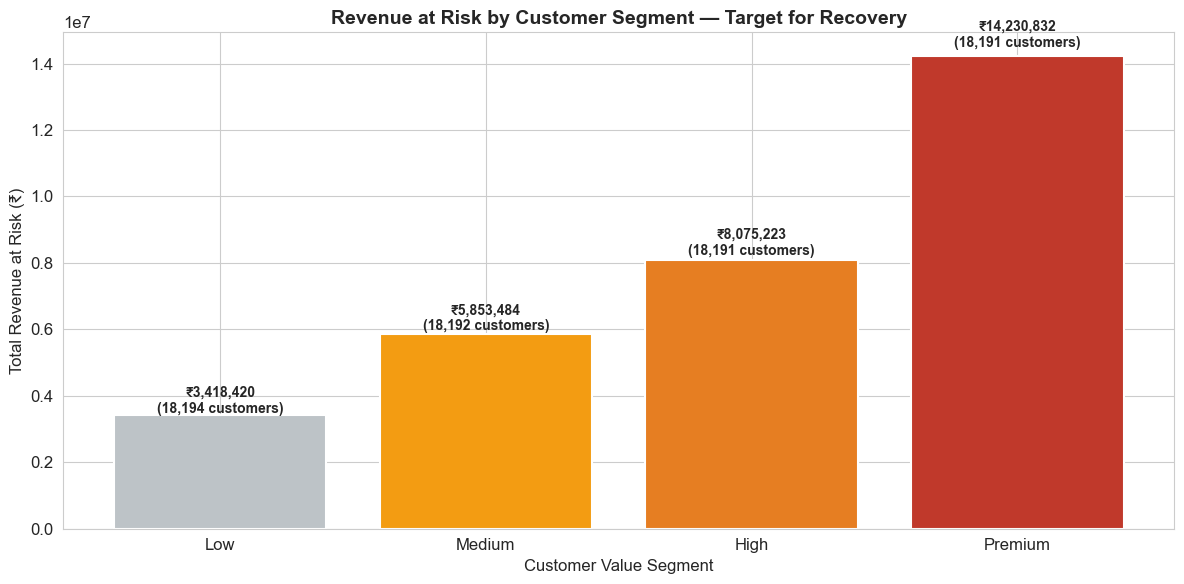

In [6]:
# --- Recovery ROI Estimation ---
fig, ax = plt.subplots(figsize=(12, 6))

segments = recovery_segments.index.tolist()
revenue = recovery_segments['total_revenue'].values
counts = recovery_segments['count'].values

colors_seg = ['#bdc3c7', '#f39c12', '#e67e22', '#c0392b']
bars = ax.bar(segments, revenue, color=colors_seg, edgecolor='white', linewidth=1.5)
for bar, val, cnt in zip(bars, revenue, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'₹{val:,}\n({cnt:,} customers)', ha='center', fontweight='bold', fontsize=10)

ax.set_title('Revenue at Risk by Customer Segment — Target for Recovery', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Revenue at Risk (₹)')
ax.set_xlabel('Customer Value Segment')
plt.tight_layout()
plt.show()

---
# 🍽️ Section 3: Restaurant Recovery Strategy

Restaurants left because the platform failed their orders. Here's how to bring them back.

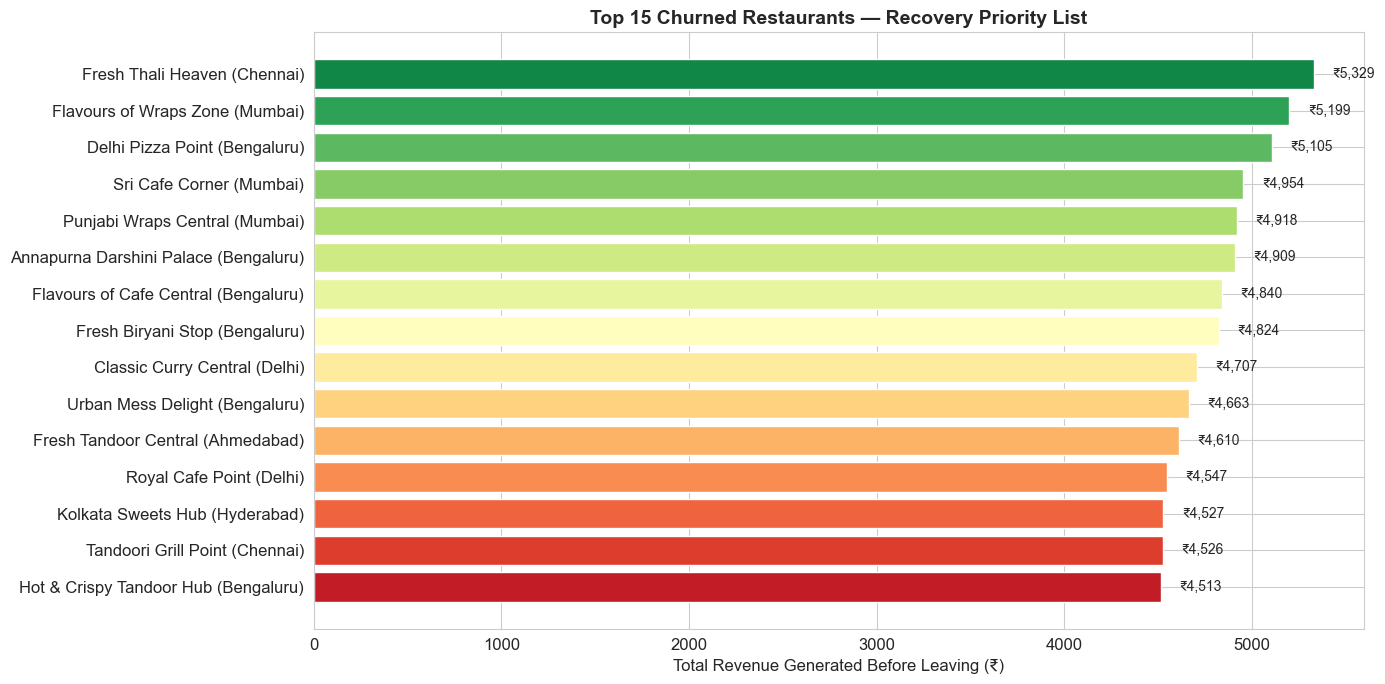

In [7]:
# --- Top Churned Restaurants for Recovery ---
rest_revenue = orders.merge(restaurant[['restaurant_id', 'restaurant_name', 'city', 'cuisine_type', 'is_active']],
                            on='restaurant_id', how='inner')
churned_rest = rest_revenue[rest_revenue['is_active'] == 'N'].groupby(
    ['restaurant_id', 'restaurant_name', 'city', 'cuisine_type']).agg(
    total_revenue=('total_amount', 'sum'),
    total_orders=('order_id', 'count'),
    cancel_rate=('is_cancelled_flag', 'mean')
).reset_index().sort_values('total_revenue', ascending=False)

churned_rest['cancel_rate_pct'] = (churned_rest['cancel_rate'] * 100).round(1)

# Top 15 recovery targets
top15 = churned_rest.head(15)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top15['restaurant_name'] + ' (' + top15['city'] + ')',
               top15['total_revenue'],
               color=sns.color_palette('RdYlGn_r', len(top15)), edgecolor='white')
for bar, val in zip(bars, top15['total_revenue']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center', fontsize=10)
ax.set_title('Top 15 Churned Restaurants — Recovery Priority List', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue Generated Before Leaving (₹)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Restaurant Recovery Action Plan

| Priority | Strategy | Details | Target |
|----------|----------|---------|--------|
| 🔴 Critical | **SLA Guarantee Program** | Commit to max 5% cancellation rate for partner orders, compensate for platform-caused failures | All restaurants |
| 🔴 Critical | **Direct CEO-Level Outreach** | Personal meetings with top 15 churned restaurants | High-revenue churned |
| 🟡 High | **Revenue Protection Fund** | Compensate restaurants ₹X per cancelled order caused by platform | All partners |
| 🟡 High | **Reduced Commission Period** | Offer 50% commission reduction for 3 months to returning restaurants | Churned restaurants |
| 🟢 Medium | **Co-Marketing Program** | Joint marketing campaigns to rebuild customer traffic for returning restaurants | Top 50 |
| 🟢 Medium | **Restaurant Dashboard** | Real-time performance metrics showing delivery and customer satisfaction | All partners |

---
# 🚚 Section 4: Delivery Operations Recovery

The delivery crisis is the root cause of everything. Here's the improvement roadmap.

In [8]:
# --- Delivery Performance Targets ---
del_with_orders = delivery.merge(orders[['order_id', 'period']], on='order_id')

del_metrics = del_with_orders.groupby('period').agg(
    avg_delay=('delay_mins', 'mean'),
    median_delay=('delay_mins', 'median'),
    on_time_pct=('delay_mins', lambda x: (x <= 0).mean() * 100),
    severe_late_pct=('delay_mins', lambda x: (x > 15).mean() * 100)
).round(2)

# Add recovery targets
del_metrics.loc['Recovery Target'] = [
    del_metrics.loc['Pre-Crisis', 'avg_delay'] * 0.9,  # 10% better than pre-crisis
    del_metrics.loc['Pre-Crisis', 'median_delay'],
    del_metrics.loc['Pre-Crisis', 'on_time_pct'] + 5,  # 5% better
    del_metrics.loc['Pre-Crisis', 'severe_late_pct'] * 0.5  # 50% reduction
]

del_metrics.columns = ['Avg Delay (min)', 'Median Delay (min)', 'On-Time %', 'Severely Late %']
del_metrics

,Avg Delay (min),Median Delay (min),On-Time %,Severely Late %
period,,,,
Crisis,17.600,17.0,12.2,54.120
Pre-Crisis,2.020,2.0,43.6,6.810
Recovery Target,1.818,2.0,48.6,3.405


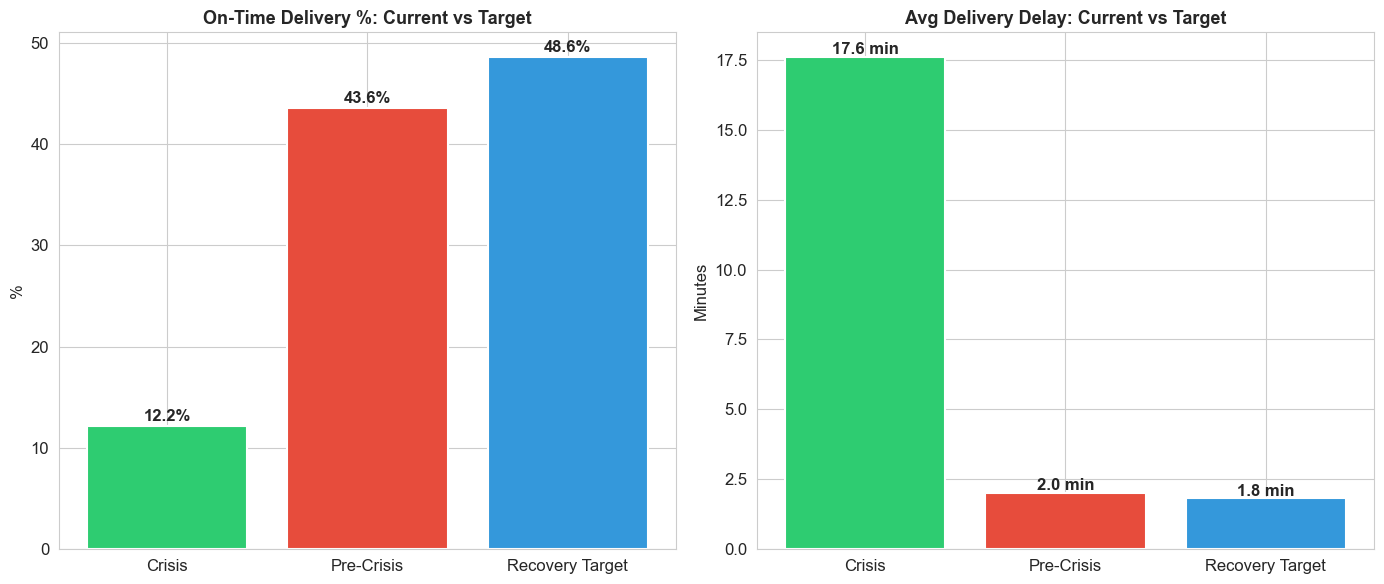

In [9]:
# --- Delivery Improvement Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

periods = del_metrics.index.tolist()
colors_bar = [COLORS['low'], COLORS['critical'], COLORS['medium']]

# On-time %
bars = axes[0].bar(periods, del_metrics['On-Time %'], color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, del_metrics['On-Time %']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('On-Time Delivery %: Current vs Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('%')

# Avg delay
bars = axes[1].bar(periods, del_metrics['Avg Delay (min)'], color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, del_metrics['Avg Delay (min)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f} min', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Avg Delivery Delay: Current vs Target', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.show()

### Delivery Operations Action Plan

| Priority | Strategy | Impact | Timeline |
|----------|----------|--------|----------|
| 🔴 Critical | **Increase delivery partner capacity** in high-demand cities | Reduce wait times, improve coverage | Week 1-4 |
| 🔴 Critical | **Weather-resilient routing** — implement rain-adjusted ETAs | Accurate expectations reduce cancellations | Week 2-6 |
| 🟡 High | **Peak-hour surge incentives** for delivery partners | More partners active during dinner rush | Week 1-2 |
| 🟡 High | **Real-time delay alerts** to customers before they complain | Proactive communication reduces frustration | Week 2-4 |
| 🟢 Medium | **Partner training program** — route optimization best practices | Gradual improvement in delivery times | Month 2-3 |
| 🟢 Medium | **Dynamic ETAs** — adjust expected time based on live conditions | Better accuracy = fewer "late" flags | Month 1-3 |

---
# 📣 Section 5: Brand & Sentiment Recovery

The crisis wasn't just operational — it damaged the brand. Here's the communication recovery plan.

C:\Users\ORACLE\AppData\Local\Temp\ipykernel_20524\1907287157.py:31: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
f:\AI Projects\FoodOrderingCrisisRecovery\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


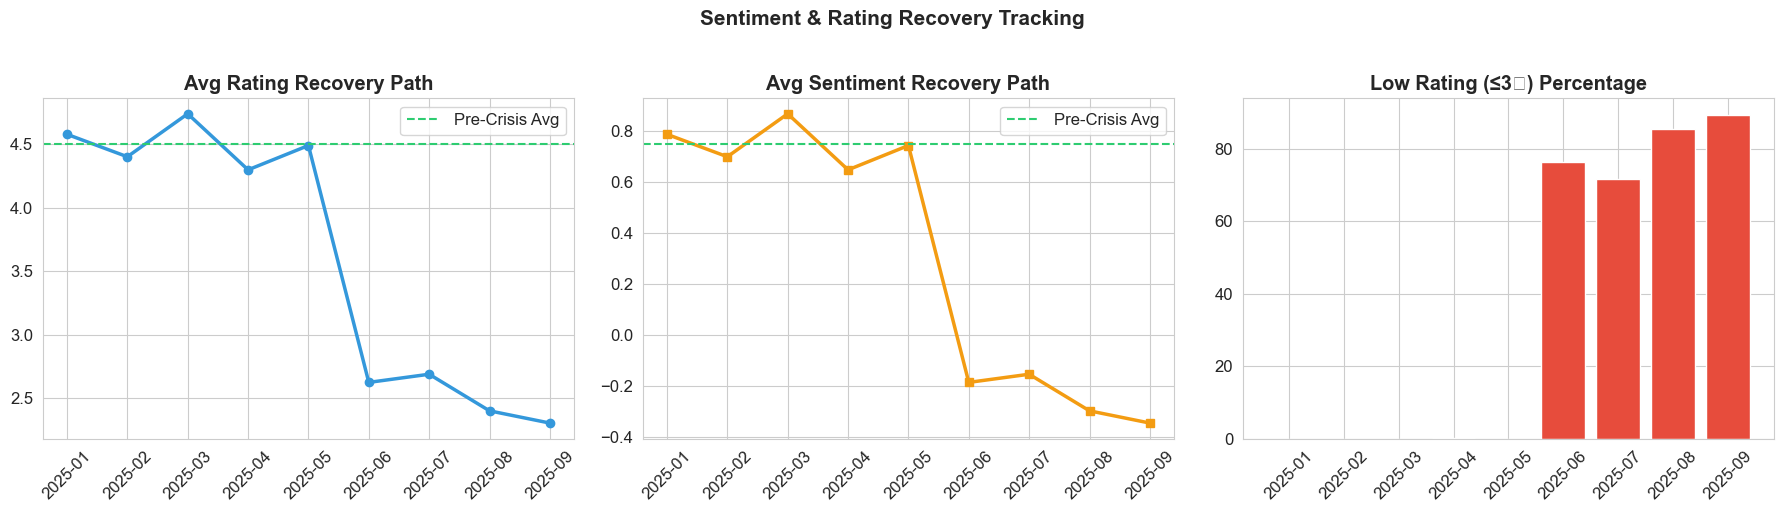

In [10]:
# --- Sentiment Recovery Tracking ---
ratings_m = ratings.copy()
ratings_m['month_str'] = ratings_m['month'].astype(str)
monthly_sent = ratings_m.groupby('month').agg(
    avg_rating=('rating', 'mean'),
    avg_sentiment=('sentiment_score', 'mean'),
    low_rating_pct=('rating', lambda x: (x <= 3).mean() * 100)
).reset_index()
monthly_sent['month_str'] = monthly_sent['month'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(monthly_sent['month_str'], monthly_sent['avg_rating'], marker='o', color=COLORS['medium'], linewidth=2.5)
axes[0].axhline(monthly_sent['avg_rating'].iloc[:5].mean(), color=COLORS['low'], linestyle='--', label='Pre-Crisis Avg')
axes[0].set_title('Avg Rating Recovery Path', fontweight='bold')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_sent['month_str'], monthly_sent['avg_sentiment'], marker='s', color=COLORS['high'], linewidth=2.5)
axes[1].axhline(monthly_sent['avg_sentiment'].iloc[:5].mean(), color=COLORS['low'], linestyle='--', label='Pre-Crisis Avg')
axes[1].set_title('Avg Sentiment Recovery Path', fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(monthly_sent['month_str'], monthly_sent['low_rating_pct'],
            color=[COLORS['low'] if i < 5 else COLORS['critical'] for i in range(len(monthly_sent))], edgecolor='white')
axes[2].set_title('Low Rating (≤3★) Percentage', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Sentiment & Rating Recovery Tracking', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Brand Recovery Action Plan

| Priority | Strategy | Channel | Timeline |
|----------|----------|---------|----------|
| 🔴 Critical | **Public acknowledgment** of service issues + commitment to improvement | Social media, app notification | Week 1 |
| 🔴 Critical | **Respond to all negative reviews** with personalized resolution | Review platforms | Week 1-ongoing |
| 🟡 High | **"We're Back" campaign** — showcase delivery improvements with real metrics | Social media, email | Month 2 |
| 🟡 High | **Influencer partnerships** — food bloggers showcasing improved service | Instagram, YouTube | Month 2-3 |
| 🟢 Medium | **Customer success stories** — highlight positive post-crisis experiences | Blog, social media | Month 3+ |
| 🟢 Medium | **Monthly transparency report** — publish delivery performance metrics | App, website | Month 2+ |

---
# 💰 Section 6: Recovery Scenarios & Financial Projections

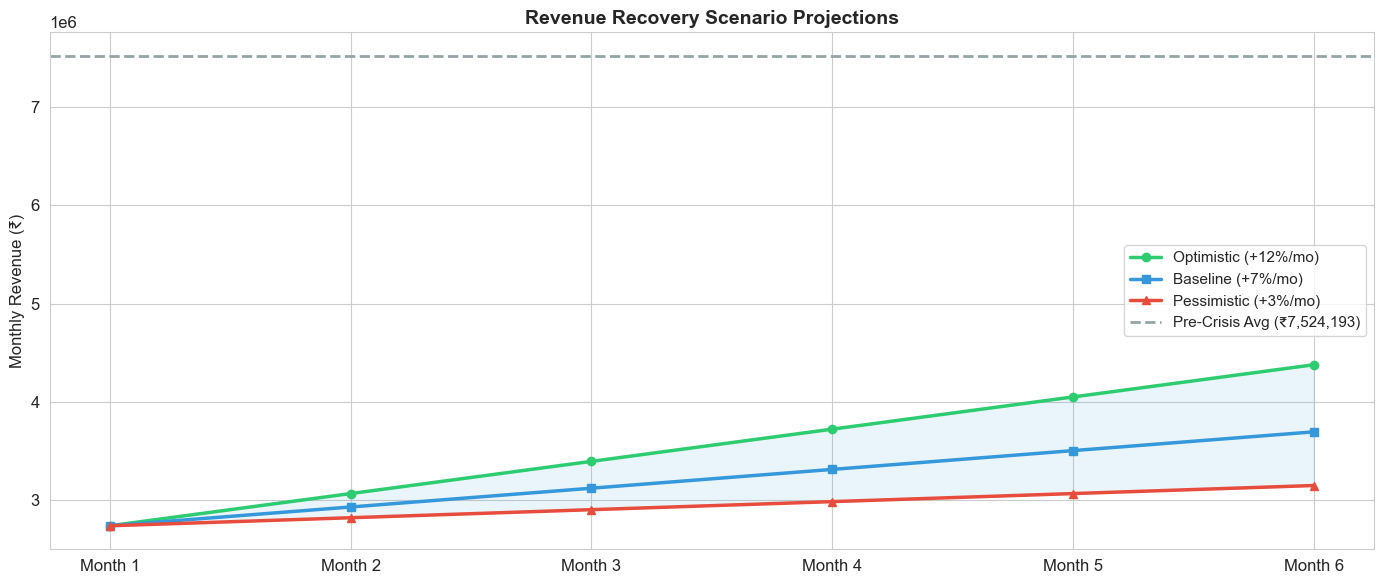

Pre-Crisis Monthly Revenue: ₹7,524,193
Current Crisis Monthly Revenue: ₹2,735,038
Gap: ₹4,789,155 (63.7%)


In [11]:
# --- Recovery Timeline Scenarios ---
pre_monthly_rev = orders[orders['period']=='Pre-Crisis'].groupby('month')['total_amount'].sum().mean()
crisis_monthly_rev = orders[orders['period']=='Crisis'].groupby('month')['total_amount'].sum().mean()

months = ['Month 1', 'Month 2', 'Month 3', 'Month 4', 'Month 5', 'Month 6']
pessimistic = [crisis_monthly_rev * (1 + 0.03 * i) for i in range(6)]
baseline = [crisis_monthly_rev * (1 + 0.07 * i) for i in range(6)]
optimistic = [crisis_monthly_rev * (1 + 0.12 * i) for i in range(6)]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(months, optimistic, marker='o', linewidth=2.5, color=COLORS['low'], label='Optimistic (+12%/mo)')
ax.plot(months, baseline, marker='s', linewidth=2.5, color=COLORS['medium'], label='Baseline (+7%/mo)')
ax.plot(months, pessimistic, marker='^', linewidth=2.5, color=COLORS['critical'], label='Pessimistic (+3%/mo)')
ax.axhline(pre_monthly_rev, color=COLORS['neutral'], linestyle='--', linewidth=2, label=f'Pre-Crisis Avg (₹{pre_monthly_rev:,.0f})')

ax.fill_between(months, pessimistic, optimistic, alpha=0.1, color=COLORS['medium'])
ax.set_title('Revenue Recovery Scenario Projections', fontsize=14, fontweight='bold')
ax.set_ylabel('Monthly Revenue (₹)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Pre-Crisis Monthly Revenue: ₹{pre_monthly_rev:,.0f}')
print(f'Current Crisis Monthly Revenue: ₹{crisis_monthly_rev:,.0f}')
print(f'Gap: ₹{pre_monthly_rev - crisis_monthly_rev:,.0f} ({(pre_monthly_rev - crisis_monthly_rev)/pre_monthly_rev*100:.1f}%)')

---
# 🗺️ Section 7: Prioritized Recovery Roadmap

## Implementation Timeline

### 🔴 Week 1-2: Emergency Stabilization
1. Fix critical delivery SLA — surge hiring of delivery partners
2. Public acknowledgment campaign across all channels
3. Freeze cancellation for orders in pipeline (reduce platform-caused cancellations)
4. Begin direct outreach to top 15 churned restaurants

### 🟡 Week 3-4: Recovery Launch
5. Launch customer win-back campaigns (Premium segment first)
6. Implement revenue protection fund for restaurant partners
7. Deploy weather-resilient routing system
8. Roll out real-time delay alerts for customers

### 🟢 Month 2-3: Sustained Recovery
9. "We're Back" marketing campaign with real improvement metrics
10. Reduced commission offers for returning restaurants
11. Loyalty program enhancement for retained customers
12. Partner training and route optimization rollout

### 🔵 Month 4-6: Growth & Prevention
13. Monthly transparency reports on delivery performance
14. Predictive models for churn prevention (early warning system)
15. Expand delivery partner network beyond current capacity needs
16. Build weather-demand forecasting for proactive planning

## Recovery KPIs to Track

| KPI | Current (Crisis) | Target (6 months) | Stretch Goal |
|-----|-------------------|--------------------|--------------|
| Monthly Active Customers | Declined | Pre-crisis level | +10% above pre-crisis |
| Cancellation Rate | Elevated | Pre-crisis level | <3% |
| On-Time Delivery % | Degraded | Pre-crisis level | >90% |
| Avg Customer Rating | Dropped | ≥4.2 | ≥4.5 |
| Active Restaurants | Reduced | Recover 50% churned | Recover 80% |
| Monthly Revenue | Collapsed | 80% of pre-crisis | 100% of pre-crisis |